In [4]:
import pandas as pd
print(pd.__version__)

2.3.0


In [5]:
df = pd.read_csv("pp-2024.csv")
df.head()

,{2131FCF5-B031-86E8-E063-4804A8C0372B},320000,2024-07-26 00:00,MK40 3SG,T,N,F,38,Unnamed: 8,GEORGE STREET,Unnamed: 10,BEDFORD,BEDFORD.1,BEDFORD.2,A,A.1
0,{2131FCF5-B034-86E8-E063-4804A8C0372B},300000,2024-02-15 00:00,MK43 9GH,S,N,F,12,NaN,BRICK CRESCENT,STEWARTBY,BEDFORD,BEDFORD,BEDFORD,A,A
1,{2131FCF5-B036-86E8-E063-4804A8C0372B},470000,2024-08-21 00:00,MK45 2BF,S,N,F,21,NaN,COLTSFOOT CORNER,AMPTHILL,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A
2,{2131FCF5-B037-86E8-E063-4804A8C0372B},527500,2024-07-29 00:00,MK43 0YX,D,N,L,1,NaN,FALLOWS CRESCENT,CRANFIELD,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A
3,{2131FCF5-B038-86E8-E063-4804A8C0372B},351000,2024-07-17 00:00,LU3 3AR,T,N,F,320,NaN,SUNDON PARK ROAD,NaN,LUTON,LUTON,LUTON,A,A
4,{2131FCF5-B03A-86E8-E063-4804A8C0372B},395000,2024-08-02 00:00,SG18 8NR,D,N,F,21,NaN,KENNETT DRIVE,NaN,BIGGLESWADE,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A


In [6]:
import pandas as pd

columns = [
    "transaction_id", "price", "date", "postcode",
    "property_type", "old_new", "tenure", "paon",
    "saon", "street", "locality", "town_city",
    "district", "county", "ppd_type", "record_status"
]

df = pd.read_csv("pp-2024.csv", header=None, names=columns)
df.head()

,transaction_id,price,date,postcode,property_type,old_new,tenure,paon,saon,street,locality,town_city,district,county,ppd_type,record_status
0,{2131FCF5-B031-86E8-E063-4804A8C0372B},320000,2024-07-26 00:00,MK40 3SG,T,N,F,38,NaN,GEORGE STREET,NaN,BEDFORD,BEDFORD,BEDFORD,A,A
1,{2131FCF5-B034-86E8-E063-4804A8C0372B},300000,2024-02-15 00:00,MK43 9GH,S,N,F,12,NaN,BRICK CRESCENT,STEWARTBY,BEDFORD,BEDFORD,BEDFORD,A,A
2,{2131FCF5-B036-86E8-E063-4804A8C0372B},470000,2024-08-21 00:00,MK45 2BF,S,N,F,21,NaN,COLTSFOOT CORNER,AMPTHILL,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A
3,{2131FCF5-B037-86E8-E063-4804A8C0372B},527500,2024-07-29 00:00,MK43 0YX,D,N,L,1,NaN,FALLOWS CRESCENT,CRANFIELD,BEDFORD,CENTRAL BEDFORDSHIRE,CENTRAL BEDFORDSHIRE,A,A
4,{2131FCF5-B038-86E8-E063-4804A8C0372B},351000,2024-07-17 00:00,LU3 3AR,T,N,F,320,NaN,SUNDON PARK ROAD,NaN,LUTON,LUTON,LUTON,A,A


In [7]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(923729, 16)
transaction_id    object
price              int64
date              object
postcode          object
property_type     object
old_new           object
tenure            object
paon              object
saon              object
street            object
locality          object
town_city         object
district          object
county            object
ppd_type          object
record_status     object
dtype: object
transaction_id         0
price                  0
date                   0
postcode            2748
property_type          0
old_new                0
tenure                 0
paon                   0
saon              803506
street             14833
locality          572954
town_city              0
district               0
county                 0
ppd_type               0
record_status          0
dtype: int64


In [8]:
df = df.dropna(subset=["postcode"])

In [9]:
df.shape

(920981, 16)

In [10]:
df["property_type"].value_counts()

property_type
S    250765
T    249140
D    209597
F    161422
O     50057
Name: count, dtype: int64

In [11]:
df["price"].describe()

count    9.209810e+05
mean     3.952801e+05
std      1.065738e+06
min      1.000000e+00
25%      1.810000e+05
50%      2.800000e+05
75%      4.250000e+05
max      1.643000e+08
Name: price, dtype: float64

In [12]:
df = df[(df["price"] > 10000) & (df["price"] < 5000000)]
print(df.shape)

(915762, 16)


In [13]:
df["price"].describe()

count    9.157620e+05
mean     3.618916e+05
std      3.389429e+05
min      1.005000e+04
25%      1.825000e+05
50%      2.800000e+05
75%      4.250000e+05
max      4.999999e+06
Name: price, dtype: float64

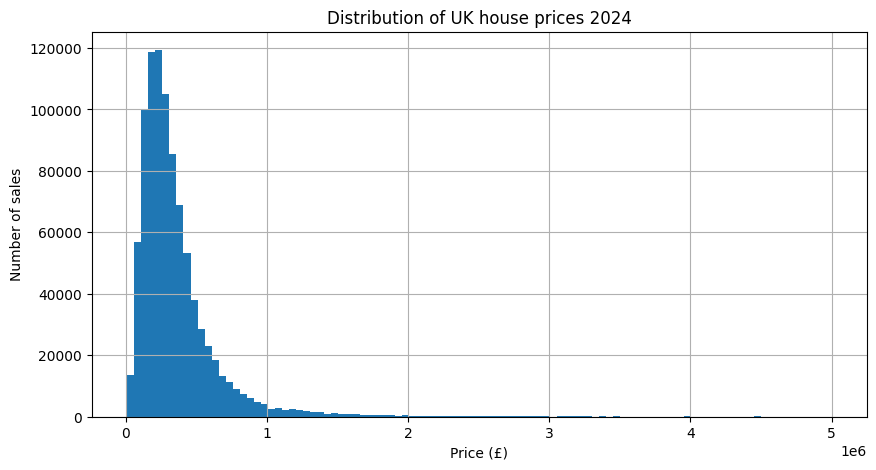

In [14]:
import matplotlib.pyplot as plt

df["price"].hist(bins=100, figsize=(10,5))
plt.xlabel("Price (£)")
plt.ylabel("Number of sales")
plt.title("Distribution of UK house prices 2024")
plt.show()

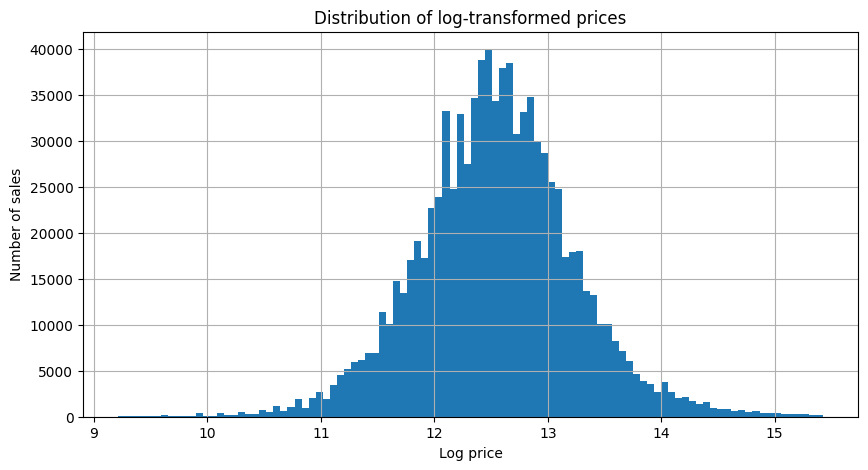

In [15]:
import numpy as np

df["price_log"] = np.log(df["price"])
df["price_log"].hist(bins=100, figsize=(10,5))
plt.xlabel("Log price")
plt.ylabel("Number of sales")
plt.title("Distribution of log-transformed prices")
plt.show()

In [16]:
df.groupby("property_type")["price"].mean()

property_type
D    498191.361890
F    316929.453453
O    589831.905247
S    312450.733225
T    284477.290459
Name: price, dtype: float64

In [17]:
df.groupby("town_city")["price"].mean().sort_values(ascending=False).head(10)

town_city
COBHAM            1.257752e+06
VIRGINIA WATER    1.237600e+06
BEACONSFIELD      1.143474e+06
RADLETT           1.084068e+06
KESTON            1.029280e+06
ESHER             1.027204e+06
EAST MOLESEY      9.934830e+05
GERRARDS CROSS    9.616066e+05
SALCOMBE          9.507228e+05
HARPENDEN         9.261708e+05
Name: price, dtype: float64

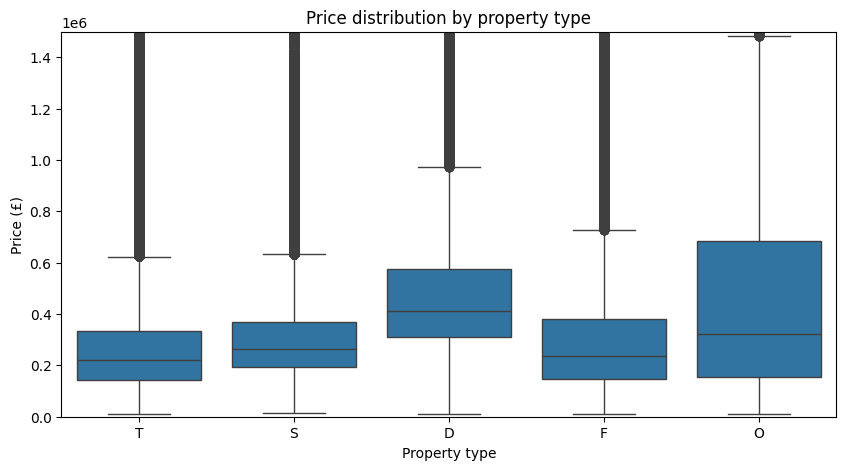

In [18]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="property_type", y="price")
plt.ylim(0, 1500000)
plt.xlabel("Property type")
plt.ylabel("Price (£)")
plt.title("Price distribution by property type")
plt.show()

In [19]:
df = pd.get_dummies(df, columns=["property_type", "tenure", "old_new"])
print(df.shape)
print(df.columns.tolist())

(915762, 23)
['transaction_id', 'price', 'date', 'postcode', 'paon', 'saon', 'street', 'locality', 'town_city', 'district', 'county', 'ppd_type', 'record_status', 'price_log', 'property_type_D', 'property_type_F', 'property_type_O', 'property_type_S', 'property_type_T', 'tenure_F', 'tenure_L', 'old_new_N', 'old_new_Y']


In [20]:
print(df.columns.tolist())

['transaction_id', 'price', 'date', 'postcode', 'paon', 'saon', 'street', 'locality', 'town_city', 'district', 'county', 'ppd_type', 'record_status', 'price_log', 'property_type_D', 'property_type_F', 'property_type_O', 'property_type_S', 'property_type_T', 'tenure_F', 'tenure_L', 'old_new_N', 'old_new_Y']


In [21]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
print(df[["date", "year", "month"]].head())

        date  year  month
0 2024-07-26  2024      7
1 2024-02-15  2024      2
2 2024-08-21  2024      8
3 2024-07-29  2024      7
4 2024-07-17  2024      7


In [22]:
features = [
    "year", "month",
    "property_type_D", "property_type_F", 
    "property_type_O", "property_type_S", "property_type_T",
    "tenure_F", "tenure_L",
    "old_new_N", "old_new_Y"
]

target = "price_log"

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(915762, 11)
(915762,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(732609, 11)
(183153, 11)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 0.6428
R²: 0.1484


In [25]:
town_mean_price = df.groupby("town_city")["price_log"].mean()
df["town_encoded"] = df["town_city"].map(town_mean_price)

In [26]:
features = [
    "year", "month",
    "property_type_D", "property_type_F", 
    "property_type_O", "property_type_S", "property_type_T",
    "tenure_F", "tenure_L",
    "old_new_N", "old_new_Y", "town_encoded"
]

target = "price_log"

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(915762, 12)
(915762,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(732609, 12)
(183153, 12)


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 0.4707
R²: 0.5433


In [29]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²: {r2_xgb:.4f}")

RMSE: 0.4449
R²: 0.5921


In [30]:

postcode_mean_price = df.groupby("postcode")["price_log"].mean()
df["postcode_encoded"] =df["postcode"].map(postcode_mean_price)

In [31]:
features = [
    "year", "month",
    "property_type_D", "property_type_F", 
    "property_type_O", "property_type_S", "property_type_T",
    "tenure_F", "tenure_L",
    "old_new_N", "old_new_Y", "town_encoded", "postcode_encoded"
]

target = "price_log"

X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

(915762, 13)
(915762,)


In [32]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(732609, 13)
(183153, 13)


In [33]:
xgb_model = XGBRegressor(n_estimators=300, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²: {r2_xgb:.4f}")

RMSE: 0.2062
R²: 0.9123


In [34]:
# Calculate mean prices using ONLY training data
train_postcode_mean = df.loc[X_train.index].groupby("postcode")["price_log"].mean()

# Map onto both train and test
X_train["postcode_encoded"] = df.loc[X_train.index, "postcode"].map(train_postcode_mean)
X_test["postcode_encoded"] = df.loc[X_test.index, "postcode"].map(train_postcode_mean)

In [35]:
xgb_model = XGBRegressor(n_estimators=300, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²: {r2_xgb:.4f}")

RMSE: 1.7560
R²: -5.3548


In [36]:
print(X_test["postcode_encoded"].isnull().sum())

75084


In [37]:
global_mean = df.loc[X_train.index, "price_log"].mean()

X_train["postcode_encoded"] = df.loc[X_train.index, "postcode"].map(train_postcode_mean).fillna(global_mean)
X_test["postcode_encoded"] = df.loc[X_test.index, "postcode"].map(train_postcode_mean).fillna(global_mean)

In [38]:
xgb_model = XGBRegressor(n_estimators=300, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²: {r2_xgb:.4f}")

RMSE: 0.5237
R²: 0.4347


In [39]:
pip install shap

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



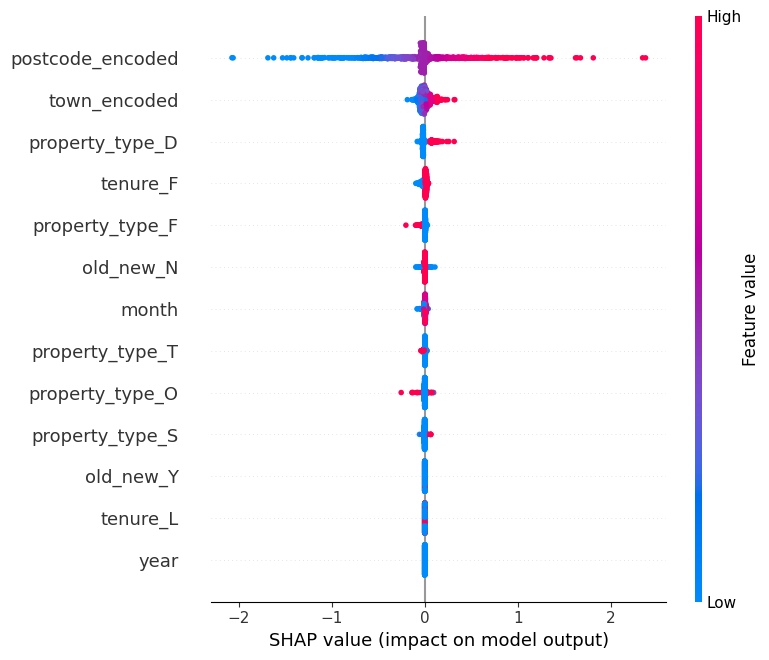

In [40]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:1000])

shap.summary_plot(shap_values, X_test[:1000])

In [41]:
import shap
print(shap.__version__)

0.51.0


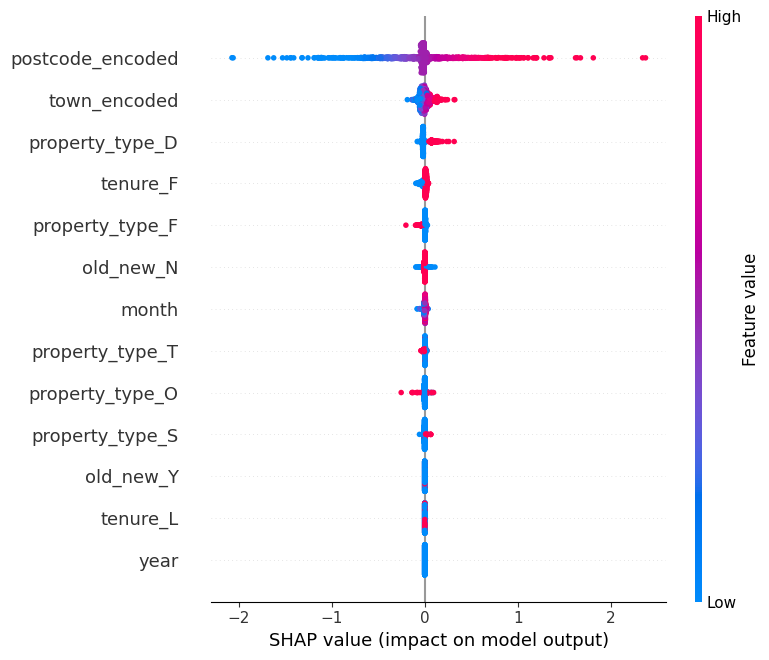

In [42]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:1000])

shap.summary_plot(shap_values, X_test[:1000])

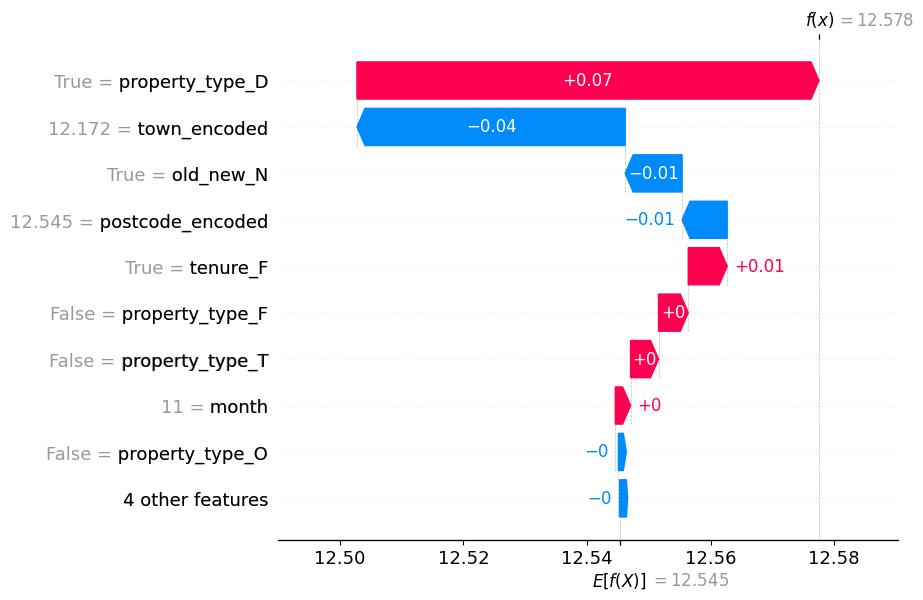

In [43]:
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))

In [44]:
import joblib
joblib.dump(xgb_model, "housing_model.joblib")

['housing_model.joblib']

In [45]:
import json

town_means_dict = town_mean_price.to_dict()
postcode_means_dict = postcode_mean_price.to_dict()

with open("town_means.json", "w") as f:
    json.dump(town_means_dict, f)

with open("postcode_means.json", "w") as f:
    json.dump(postcode_means_dict, f)